<h1> Import

In [1]:

from masterthesis.data.loaders import load_cell_dataframe
from masterthesis.data.datasets import balanced_subsampled_env_dict
from masterthesis.data.preprocessing import preprocess_env_data
from masterthesis.data.dataset_object import make_environment_dataset, make_observational_dataset

from masterthesis.algorithms.notears import run_notears
from masterthesis.algorithms.pc import run_pc
from masterthesis.algorithms.dotears import run_dotears

from masterthesis.experiments import run_algorithms
from masterthesis.evaluation import load_all_dags, dag_frequency_matrix
from masterthesis.visualization import plot_dag_frequency_heatmap, save_graph_plot

import numpy as np


<h1> Single Cell

<h2> Data

In [ ]:
cell_df = load_cell_dataframe()

# downsample
cell_df = cell_df.iloc[::10]

cell_df.head()


,CellID,CurrentData,VoltageData,TempData,StepIndex,CycleIndex,TimeData
0,GS3,0.0,4.197761,24.041702,9,1,0.0000
10,GS3,0.0,4.197698,24.023285,9,1,10.0003
20,GS3,0.0,4.196752,23.888824,9,1,20.0004
30,GS3,0.0,4.196815,23.962847,9,1,30.0001
40,GS3,0.0,4.196689,24.058426,9,1,40.0004


In [ ]:
cols = ["CurrentData", "VoltageData", "TempData", "CycleIndex"]

groups = [
    [9, 11, 13, 15, 22],   # rest
    [10],                  # strong discharge
    [12],                  # medium discharge
    [14],                  # charge
    [17,18,19,20,21]       # dynamic experiments
]

env_df = balanced_subsampled_env_dict(cell_df, cols, groups, sort_by="StepIndex", max_samples_per_env=5000, seed=42)
print(env_df[0].shape)
print(env_df[4].shape)

<h3> Preprocessing (scaling+noise)

In [4]:
env_data = preprocess_env_data(
    env_df,
    scale=True,
    noise_std=0.0000000000001,
    seed=42,
)


dict_keys([np.int64(0), np.int64(4)])
after scale: [2.28983499e-16 8.85689835e-03 9.23685102e-01 6.57252031e-14]
after noise: [1.01232796e-13 8.85689835e-03 9.23685102e-01 1.01955564e-13]


<h3> Dataset

In [5]:
interventions = {
    0: [],     # rest = observational
    1: [0],    # discharge
    2: [0],    # discharge
    3: [0],    # charge
    4: [0],    # dynamic excitation
}
dataset = make_environment_dataset(env_data, interventions)

X_obs = np.vstack(list(env_data.values()))
dataset_obs = make_observational_dataset(X_obs)


In [6]:
print(dataset["X"].shape)
print(dataset["X"][:10])
print(dataset["X"].std(axis=0))


(10000, 4)
[[-0.02666722  0.74337476 -0.33176507 -0.67895471]
 [-0.02666722  0.7411806   0.17590149 -0.67895471]
 [-0.02666722  0.73677725 -0.3687714  -0.67895471]
 [-0.02666722  0.73675385 -1.37160743 -0.67895471]
 [-0.02666722  0.73811747 -1.57854629 -0.67895471]
 [-0.02666722  0.74049378 -0.27453956 -0.67895471]
 [-0.02666722  0.7366469  -0.657016   -0.67895471]
 [-0.02666722  0.75313734 -0.23459082 -0.67895471]
 [-0.02666722  0.73908003 -1.33495084 -0.67895471]
 [-0.02666722  0.74495562 -0.72938244 -0.67895471]]
[1. 1. 1. 1.]


In [7]:
import pandas as pd

pd.DataFrame(dataset["X"], columns=cols).corr()

,CurrentData,VoltageData,TempData,CycleIndex
CurrentData,1.000000,0.172810,0.079558,0.017184
VoltageData,0.172810,1.000000,-0.073065,-0.970448
TempData,0.079558,-0.073065,1.000000,0.065121
CycleIndex,0.017184,-0.970448,0.065121,1.000000


In [8]:
for k,v in env_data.items():
    print(k, v.shape)

0 (5000, 4)
4 (5000, 4)


In [9]:
print(dataset['envs'])

{np.int64(0): array([[-0.02666722,  0.74337476, -0.33176507, -0.67895471],
       [-0.02666722,  0.7411806 ,  0.17590149, -0.67895471],
       [-0.02666722,  0.73677725, -0.3687714 , -0.67895471],
       ...,
       [-0.02666722,  0.73722845, -1.40688375, -0.67895471],
       [-0.02666722,  0.74773466,  2.00902036, -0.67895471],
       [-0.02666722,  0.7585116 , -0.22420145, -0.67895471]]), np.int64(4): array([[ 0.05304455, -2.5307605 , -1.75192952,  2.42412897],
       [-0.42868735, -1.63359172, -1.77745997,  1.64835805],
       [ 0.4420956 , -0.15226663, -0.29847057,  0.09681621],
       ...,
       [-0.44300548, -0.10787798, -0.83770163, -0.29106925],
       [-0.24041794, -0.54423367,  1.04437508,  0.48470167],
       [ 0.00523684, -1.15232099,  2.5042691 ,  1.26047259]])}


<h2> PC

In [10]:
dag_pc = run_pc(dataset)
print(dag_pc)

  0%|          | 0/4 [00:00<?, ?it/s]

[[0 1 1 0]
 [1 0 1 1]
 [1 1 0 1]
 [0 1 1 0]]


<h2> No-Tears

In [11]:
dag_notears = run_notears(dataset_obs)
print(dag_notears)

100%|██████████| 20/20 [00:02<00:00,  8.78it/s]

[[0 0 0 0]
 [1 0 1 1]
 [0 0 0 0]
 [1 0 1 0]]


<h2> Third alg-Do Tears

In [12]:
dag_dotears = run_dotears(dataset, scaled=True)
print(dag_dotears)

0 h = 0.22140455377513213
1 h = 0.05320838190806221
2 h = 0.012846246789078641
3 h = 0.002764538237491898
4 h = 0.0006152781634600757
5 h = 0.0001440780144346121
6 h = 3.388642511570339e-05
7 h = 7.476626659119745e-06
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]]


<h2> Third alg- GIES

<h2> Compare/Results?

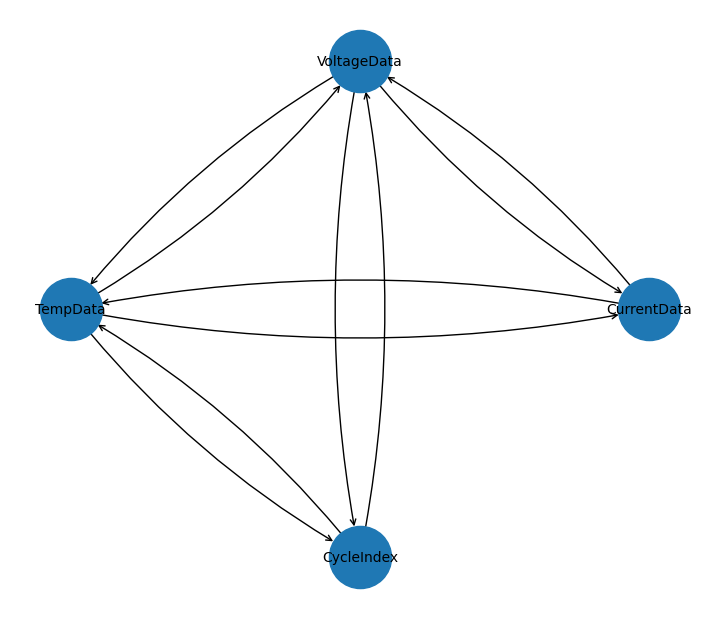

In [13]:
save_graph_plot(cols, dag_pc) 

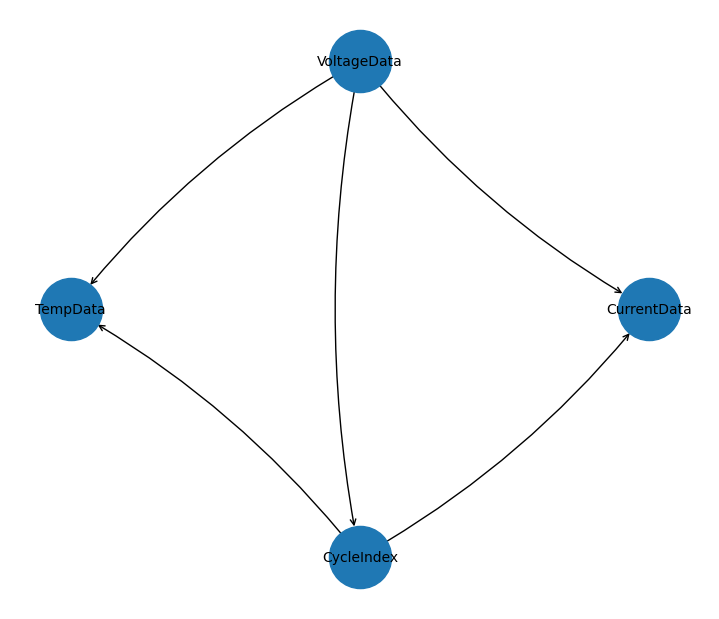

In [14]:
save_graph_plot(cols, dag_notears) 

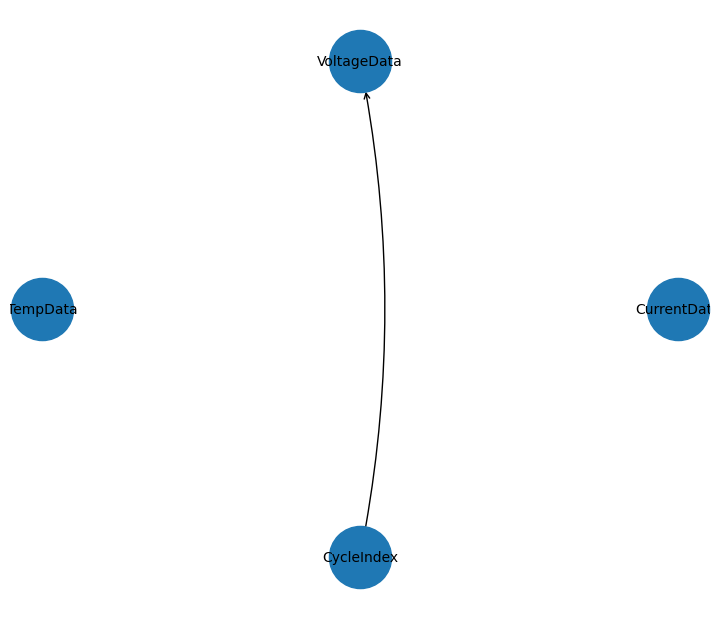

In [15]:
save_graph_plot(cols, dag_dotears) 